# Methoden en Technieken -- Blok 2

## Datapunt 2b,

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en
technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model** en
kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen, rekening
houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-
oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld machine learning, deep learning, kennisrepresentatie, computer vision** en natural language
processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch
proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability,
explainability, **model complexity** en resource demand.

Dit is een individuele opdracht. Het is toegestaan met elkaar de opdracht te bespreken, maar iedereen schrijft zijn eigen code en antwoorden. Mocht je code van het internet hebben overgenomen/aangepast, vermeld dan de bron in het commentaar. Het gebruik van generatieve AI (Chat-GPT, etc...) is *alleen* toegestaan bij de voorbereiding op de opdracht. Denk hierbj aan activiteiten zoals brainstormen, of het maken van een plan. Het is niet toegestaan code of tekst van generative AI over te nemen. (Level 2 van de AI Assessment Scale)

Als je gebruik maakt van bronnen om jouw keuzes te verantwoorden willen we bij deze opdracht het volgende zien:
- De bronverwijzing (online link indien beschikbaar)
- De uitspraak die jij doet
- Paragraafnummer uit de bron waar je deze uitspraak op baseert
- Een letterlijke quote uit de bron waar je jouw uitspraak op baseert

(Merk op: dit is veel uitgebreider dan wat er meestal in rapporten verwacht wordt, en is puur bedoeld te controleren of de student correct kan verwijzen.)

Voorbeeld:
> De laatste jaren zijn GANs veel minder populair als generatieve modellen [1] (H17: "(GANs) have gradually fallen out of fashion in recent years and have been all but replaced by diffusion models")
>
> ...
>
> Bronnenlijst:
>
> [1] F. Chollet and M. Watson, Deep Learning in Python, 3rd edition, Manning, 2025. 

https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter17_image-generation.ipynb

base model


## De opdracht

De volgende code laadt de data in. Dit is een gedeeltelijk gelabelde variant van de MNIST dataset

In [27]:
#| include: false

# Standard library
import os
import pickle

# Environment configuration
os.environ["KERAS_BACKEND"] = "torch"

# Core numerical and ML libraries
import numpy as np
import torch
import keras
from keras import layers, Model, Input, optimizers

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import visualkeras

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# 3d visualisation
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif

# Hardware check
if torch.cuda.is_available():
    print('Notebook gebruikt windows GPU')
elif torch.mps.is_available():
    print('Notebook gebruikt apple GPU')
else:
    print('Notebook gebruikt CPU')


# Data loading
with open('data_2b_new.pkl', 'rb') as file:
    x_labeled, y_labeled, x_unlabeled = pickle.load(file)


ModuleNotFoundError: No module named 'plotly'

### Helper functions for iterations (save, load, plot)

In [46]:
def _resolve_history_dict(history_or_dict):
    if history_or_dict is None:
        raise ValueError("history_or_dict is None.")
    # Keras History object
    hist = getattr(history_or_dict, 'history', None)
    if isinstance(hist, dict):
        return hist
    # Already a dict-like
    if isinstance(history_or_dict, dict):
        return history_or_dict
    raise TypeError("Expected a Keras History or dict of lists.")


def plot_training_curves(history, title_prefix=None):
    """Plot train/val curves for common metrics.

    Supports: loss, accuracy (various), and extra pairs like reconstruction_loss/kl_loss if present.
    """
    h = _resolve_history_dict(history)
    keys = set(h.keys())

    # Primary pairs
    pairs = []
    if 'loss' in keys or 'val_loss' in keys:
        pairs.append(('loss', 'val_loss'))

    # Accuracy candidates
    acc_candidates = ['accuracy', 'sparse_categorical_accuracy', 'categorical_accuracy', 'binary_accuracy']
    acc_key = next((k for k in acc_candidates if k in keys), None)
    if acc_key:
        pairs.append((acc_key, f'val_{acc_key}'))

    # Extra VAE metrics if present
    for base in ['reconstruction_loss', 'kl_loss']:
        train_k = base
        val_k = f'val_{base}'
        if train_k in keys or val_k in keys:
            pairs.append((train_k, val_k))

    if not pairs:
        # Fallback: plot any available series
        for k in sorted(keys):
            vk = f'val_{k}'
            pairs.append((k, vk))

    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 4))
    if n == 1:
        axes = [axes]

    # Determine epochs from first available series length
    ref_series = next((h[p[0]] for p in pairs if p[0] in h and isinstance(h[p[0]], (list, tuple)) and len(h[p[0]])>0), None)
    if ref_series is None:
        ref_series = next((h[p[1]] for p in pairs if p[1] in h and isinstance(h[p[1]], (list, tuple)) and len(h[p[1]])>0), None)
    num_epochs = len(ref_series) if ref_series is not None else None
    epochs = range(1, (num_epochs or 0) + 1)

    for ax, (train_k, val_k) in zip(axes, pairs):
        plotted = False
        if train_k in h and isinstance(h[train_k], (list, tuple)):
            ax.plot(epochs, h[train_k], label=f"Train {train_k}")
            plotted = True
        if val_k in h and isinstance(h[val_k], (list, tuple)):
            ax.plot(epochs, h[val_k], label=f"Val {train_k}")
            plotted = True
        ax.set_title(f"{title_prefix+' - ' if title_prefix else ''}{train_k}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(train_k)
        ax.grid(True, alpha=0.3)
        if plotted:
            ax.legend()
        else:
            ax.set_visible(False)

    plt.tight_layout()
    plt.show()


def save_model_and_history(model, history, name='model', models_dir='models'):
    """Save model weights and training history to disk.
    
    Args:
        model: Keras model to save
        history: Training history (Keras History object or dict)
        name: Base name for saved files (no extension needed)
        models_dir: Directory to save in (default: 'models')
    
    Returns:
        Dict with 'weights' and 'history' paths
    """
    os.makedirs(models_dir, exist_ok=True)
    weights_path = os.path.join(models_dir, f"{name}.weights.h5")
    hist_path = os.path.join(models_dir, f"{name}_hist.pkl")

    # Save weights
    model.save_weights(weights_path)

    # Save history dict
    h = _resolve_history_dict(history)
    with open(hist_path, 'wb') as f:
        pickle.dump(h, f)

    print(f"Saved weights → {weights_path}")
    print(f"Saved history → {hist_path}")
    return {"weights": weights_path, "history": hist_path}


def load_vae_weights(vae, name, models_dir='models'):
    """Load VAE weights if file exists.
    
    Args:
        vae: VAE model to load weights into
        name: Base name of saved file (no extension needed)
        models_dir: Directory to load from (default: 'models')
    
    Returns:
        True if loaded successfully, False otherwise
    """
    weights_path = os.path.join(models_dir, f"{name}.weights.h5")
    if not os.path.exists(weights_path):
        print(f"Warning: VAE weights not found at {weights_path}")
        return False
    vae.load_weights(weights_path)
    print(f"Loaded VAE weights from: {weights_path}")
    return True

def load_history(name, models_dir='models'):
    """Load training history from disk.
    
    Args:
        name: Base name of saved file (no extension needed)
        models_dir: Directory to load from (default: 'models')
    
    Returns:
        History dict if file exists, None otherwise
    """
    hist_path = os.path.join(models_dir, f"{name}_hist.pkl")
    if not os.path.exists(hist_path):
        print(f"Warning: History not found at {hist_path}")
        return None
    with open(hist_path, 'rb') as f:
        history = pickle.load(f)
    print(f"Loaded history from: {hist_path}")
    return history

def analyze_active_dimensions(vae, x_data, threshold=0.01):
    """Analyze active latent dimensions in a VAE.
    
    Calculates variance of z_mean across samples to identify which
    latent dimensions are actively used by the model.
    
    Args:
        vae: Trained VAE model with encoder
        x_data: Input data to encode (N, H, W, C)
        threshold: Variance threshold for considering dimension "active"
    
    Returns:
        Dict with 'variances', 'active_dims', 'n_active' keys
    """
    # Encode data
    z_mean, z_log_var = vae.encoder.predict(x_data, verbose=0)
    
    # Calculate variance per dimension
    variances = np.var(z_mean, axis=0)
    
    # Identify active dimensions
    active_mask = variances > threshold
    n_active = np.sum(active_mask)
    active_dims = np.where(active_mask)[0]
    
    # Plot variance per dimension
    latent_dim = z_mean.shape[1]
    plt.figure(figsize=(10, 4))
    plt.bar(range(latent_dim), variances, color=['green' if v > threshold else 'lightgray' for v in variances])
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Latent Dimension')
    plt.ylabel('Variance')
    plt.title(f'Active Dimensions: {n_active}/{latent_dim}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Active dimensions: {n_active}/{latent_dim}")
    print(f"Active indices: {active_dims.tolist()}")
    print(f"Variances: {variances}")
    
    return {
        'variances': variances,
        'active_dims': active_dims,
        'n_active': n_active
    }


def plot_latent_space(vae, x_data, y_labels, title='Latent Space Visualization', method='pca'):
    """Visualize latent space and class separation.
    
    For 2D latent spaces, plots directly. For higher dimensions,
    reduces to 2D using PCA or t-SNE for visualization.
    
    Args:
        vae: Trained VAE model with encoder
        x_data: Input data to encode (N, H, W, C)
        y_labels: Class labels for coloring (N,)
        title: Plot title
        method: 'pca' or 'tsne' for dimensionality reduction
    
    Returns:
        z_mean: Encoded latent representations
    """
    # Import dimensionality reduction tools
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    
    # Encode data
    z_mean, z_log_var = vae.encoder.predict(x_data, verbose=0)
    latent_dim = z_mean.shape[1]
    
    # Prepare data for plotting
    if latent_dim == 2:
        z_plot = z_mean
        x_label, y_label = 'Latent Dim 0', 'Latent Dim 1'
    elif latent_dim > 2:
        if method == 'pca':
            reducer = PCA(n_components=2, random_state=42)
            z_plot = reducer.fit_transform(z_mean)
            var_explained = reducer.explained_variance_ratio_
            x_label = f'PC1 ({var_explained[0]:.1%} var)'
            y_label = f'PC2 ({var_explained[1]:.1%} var)'
        elif method == 'tsne':
            reducer = TSNE(n_components=2, random_state=42, perplexity=min(30, len(x_data)-1))
            z_plot = reducer.fit_transform(z_mean)
            x_label, y_label = 't-SNE 1', 't-SNE 2'
        else:
            raise ValueError(f"Unknown method: {method}. Use 'pca' or 'tsne'.")
        title = f"{title} ({method.upper()}: {latent_dim}D → 2D)"
    else:
        raise ValueError(f"Latent dimension must be >= 2, got {latent_dim}")
    
    # Create scatter plot colored by class
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_plot[:, 0], z_plot[:, 1], 
                         c=y_labels, cmap='tab10', 
                         alpha=0.6, edgecolors='k', linewidth=0.5)
    plt.colorbar(scatter, label='Class')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return z_mean

In [3]:
print(f"Observations — labeled: {x_labeled.shape[0]}, unlabeled: {x_unlabeled.shape[0]}")

Observations — labeled: 250, unlabeled: 69750


## Split strategy

De data is 250 gelabelde voorbeelden van de MNIST data set en 69750 ongelabelde voorbeelde van de dataset. Volgens de opdracht gever is de data set een split van de orginele MNIST. Omdat ik al voor kennis heb van de dataset en de orginele data al goed gebalanceerd is kies ik er voor om een normale split zonder stratify te doen.

In [165]:
# Train/Val/Test split for labeled data (no test labels kept in memory)
RANDOM_SEED = 42

# First split: training set (80%) and temp set for val+test (20%)
x_train, x_temp, y_train, y_temp = train_test_split(
    x_labeled,
    y_labeled,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_labeled
)

# Second split: split temp evenly into validation and test (10% each)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

# Print shapes for visibility
print("Split complete:")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val:", x_val.shape, "y_val:", y_val.shape)
print("x_test (held out):", x_test.shape)

# Safety: remove test references to avoid accidental use

# del x_test, y_test


Split complete:
x_train: (200, 28, 28, 1) y_train: (200,)
x_val: (25, 28, 28, 1) y_val: (25,)
x_test (held out): (25, 28, 28, 1)


De opdracht is om een *semi-supervised* model te trainen dat deze data zo goed mogelijk (rekening houdend met tijd en beschikbare hardware) kan classificeren. De enige voorwaarde is dat dit model gebruik moet maken van een *variational auto encoder* die unsupervised getrained is op deze data. Zie onder andere lessen 11, 12 en 13 van M&T blok 2 voor inspiratie.

Je zult waarschijnlijk meerdere iteraties op beide het *unsupervised* (de VAE) gedeelte en het *supervised* gedeelte van je model doorlopen. Zorg dat deze iteraties duidelijk in je notebook beschreven staan, wis ze niet!

### Deel 1

Voer een data preparatie/verkenning uit, leg kort uit wat je opvalt. Stel op basis hiervan een korte lijst van *requirements* op waar je model aan moet voldoen.

x_train: (200, 28, 28, 1) uint8
y_train: (200,) uint8
x_unlabeled: (69750, 28, 28, 1) float32
x_train pixels -> min: 0.000, max: 1.000, mean: 0.130, std: 0.307
x_unlabeled pixels -> min: 0.000, max: 1.000, mean: 0.131, std: 0.308
Train labels gevonden: [0 1 2 3 4 5 6 7 8 9]
Train per-klasse aantallen: {np.uint8(0): np.int64(24), np.uint8(1): np.int64(24), np.uint8(2): np.int64(15), np.uint8(3): np.int64(17), np.uint8(4): np.int64(16), np.uint8(5): np.int64(30), np.uint8(6): np.int64(16), np.uint8(7): np.int64(19), np.uint8(8): np.int64(17), np.uint8(9): np.int64(22)}


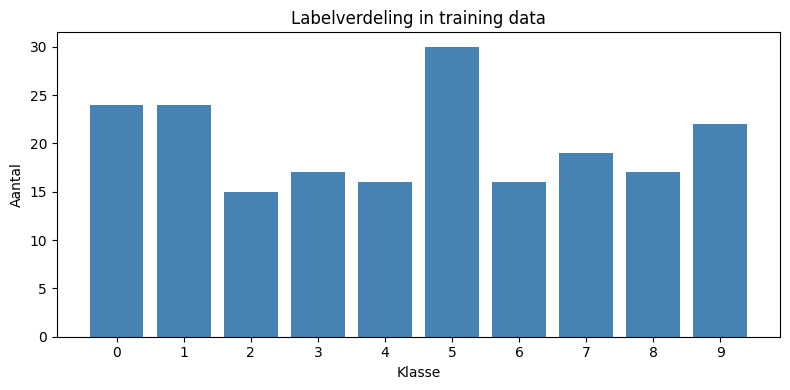

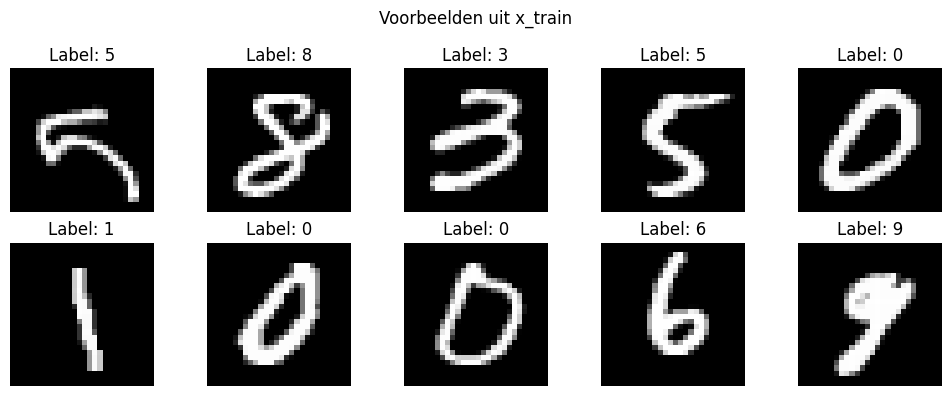

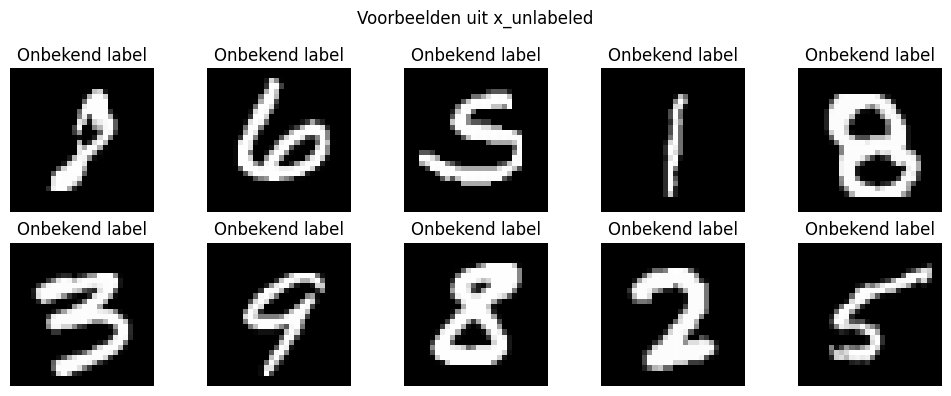

In [5]:
# Data-exploratie voor Datapunt 2b (MNIST variant, deels gelabeld)
# Basisinformatie (alleen TRAIN + unlabeled; geen VAL/TEST)
print("x_train:", x_train.shape, y_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_unlabeled:", x_unlabeled.shape, x_unlabeled.dtype)

# Stats helper

def describe_pixels(name, arr):
    arr_min = float(np.min(arr))
    arr_max = float(np.max(arr))
    arr_mean = float(np.mean(arr))
    arr_std = float(np.std(arr))
    print(f"{name} pixels -> min: {arr_min:.3f}, max: {arr_max:.3f}, mean: {arr_mean:.3f}, std: {arr_std:.3f}")

# Alleen TRAIN en UNLABELED verkennen (geen VAL/TEST)
describe_pixels("x_train", x_train)
describe_pixels("x_unlabeled", x_unlabeled)

# Labelverdeling (alleen TRAIN)
unique_labels, label_counts = np.unique(y_train, return_counts=True)
print("Train labels gevonden:", unique_labels)
print("Train per-klasse aantallen:", dict(zip(unique_labels, label_counts)))

plt.figure(figsize=(8,4))
plt.bar(unique_labels, label_counts, color="steelblue")
plt.title("Labelverdeling in training data")
plt.xlabel("Klasse")
plt.ylabel("Aantal")
plt.xticks(unique_labels)
plt.tight_layout()
plt.show()

# Enkele voorbeeldafbeeldingen (TRAIN)
n_show = 10
rng = np.random.default_rng(42)
idx_l = rng.choice(len(x_train), size=n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.flat, idx_l):
    img = x_train[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {int(y_train[i])}")
    ax.axis("off")
fig.suptitle("Voorbeelden uit x_train")
plt.tight_layout()
plt.show()

# Enkele voorbeeldafbeeldingen (ONGELABELD)
idx_u = rng.choice(len(x_unlabeled), size=n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.flat, idx_u):
    img = x_unlabeled[i]
    ax.imshow(img, cmap="gray")
    ax.set_title("Onbekend label")
    ax.axis("off")
fig.suptitle("Voorbeelden uit x_unlabeled")
plt.tight_layout()
plt.show()

> Jouw antwoorden hier, voeg gerust cellen toe

## Baseline model - OLD

Het baseline model is de versie uit keras/cholet/docent notebook met een classification head toegevoegd na het trainen van de VAE om een minimale setup te maken vom performance mee te meten. Voor dfe evaluatie zal ik het mode als een geheel beschouwen voor het itereren omdat het doel is een zo goed mogelijk model te maken met zo min mogelijke complexity.

In [6]:
# baseline_inputs = Input(shape=(28, 28, 1), name="baseline_input")
# x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(baseline_inputs)
# x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
# x = layers.Flatten()(x)
# x = layers.Dense(16, activation="relu", name="pre_z_dense")(x)  # same layer as in VAE encoder
# baseline_outputs = layers.Dense(10, activation="softmax", name="baseline_logits")(x)
# baseline_model = Model(baseline_inputs, baseline_outputs, name="baseline_cnn_classifier")

# baseline_model.compile(optimizer=optimizers.Adam(),
#                        loss="sparse_categorical_crossentropy",
#                        metrics=["accuracy"]) 

# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss", patience=12, restore_best_weights=True, min_delta=1e-4, verbose=1
# )

# baseline_hist = baseline_model.fit(
#     x_train, y_train,
#     validation_data=(x_val, y_val),
#     epochs=200,
#     batch_size=128,
#     callbacks=[early_stop],
#     verbose=1
# )

### Deel 2

Maak een eerste model en verbeter dit via een iteratief en systematisch proces.

## Sampler & VAE architecture

In [93]:
class Sampler(keras.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator()
        self.built = True

    def call(self, z_mean, z_log_var):
        batch_size = keras.ops.shape(z_mean)[0]
        z_size = keras.ops.shape(z_mean)[1]
        epsilon = keras.random.normal(
            (batch_size, z_size), seed=self.seed_generator
        )
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon
    
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=None, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampler()

        # beta handling
        self.beta = beta

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        return self.encoder(inputs)

    def compute_loss(self, x, y, y_pred, sample_weight=None, training=True):
        z_mean, z_log_var = y_pred
        reconstruction = self.decoder(self.sampler(z_mean, z_log_var))

        reconstruction_loss = keras.ops.mean(
            keras.ops.sum(
                keras.ops.binary_crossentropy(x, reconstruction), axis=(1, 2)
            )
        )

        kl_loss = -0.5 * (
            1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var)
        )
        kl_loss = keras.ops.mean(kl_loss)

        # apply beta only if provided
        if self.beta is not None:
            total_loss = reconstruction_loss + self.beta * kl_loss
        else:
            total_loss = reconstruction_loss + kl_loss

        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return total_loss

## Base model 

### VAE

In [8]:

latent_dim = 2

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


In [9]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/100


c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - kl_loss: 2.1793 - loss: 213.9487 - reconstruction_loss: 211.7664 - val_kl_loss: 2.2502 - val_loss: 191.3973 - val_reconstruction_loss: 189.1471
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - kl_loss: 2.8300 - loss: 185.1685 - reconstruction_loss: 182.3372 - val_kl_loss: 3.8915 - val_loss: 175.5897 - val_reconstruction_loss: 171.6983
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - kl_loss: 3.9122 - loss: 168.2189 - reconstruction_loss: 164.3060 - val_kl_loss: 4.0384 - val_loss: 164.1125 - val_reconstruction_loss: 160.0746
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - kl_loss: 3.9835 - loss: 162.2209 - reconstruction_loss: 158.2376 - val_kl_loss: 4.0106 - val_loss: 160.7467 - val_reconstruction_loss: 156.7364
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - kl_loss: 3.9827 - loss: 159.5532 - reconstruction_loss: 155.5708 - val_kl_loss: 4.0242 - val_loss: 158.3573 - val_reconstruction_loss: 154.3334
Epoch 6

### Save base model VAE

In [10]:
# Save base VAE model and history using reusable function
paths = save_model_and_history(vae, hist, name='base_model')

Saved weights → models\base_model.weights.h5
Saved history → models\base_model_hist.pkl


### Base model (Classifier)

In [11]:
# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1500 - loss: 2.2853 - val_accuracy: 0.2000 - val_loss: 2.2123
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1500 - loss: 2.2825 - val_accuracy: 0.2000 - val_loss: 2.2099
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1600 - loss: 2.2797 - val_accuracy: 0.2000 - val_loss: 2.2075
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1600 - loss: 2.2771 - val_accuracy: 0.2000 - val_loss: 2.2051
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1600 - loss: 2.2745 - val_accuracy: 0.2000 - val_loss: 2.2027
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1650 - loss: 2.2718 - val_accuracy: 0.2000 - val_loss: 2.2003
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1750 - loss: 2.2691 - val_accuracy: 0.2000 - val_loss: 2.1979
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1900 - loss: 2.2665 - val_accuracy: 0.2000 - v

## Evaluate base model

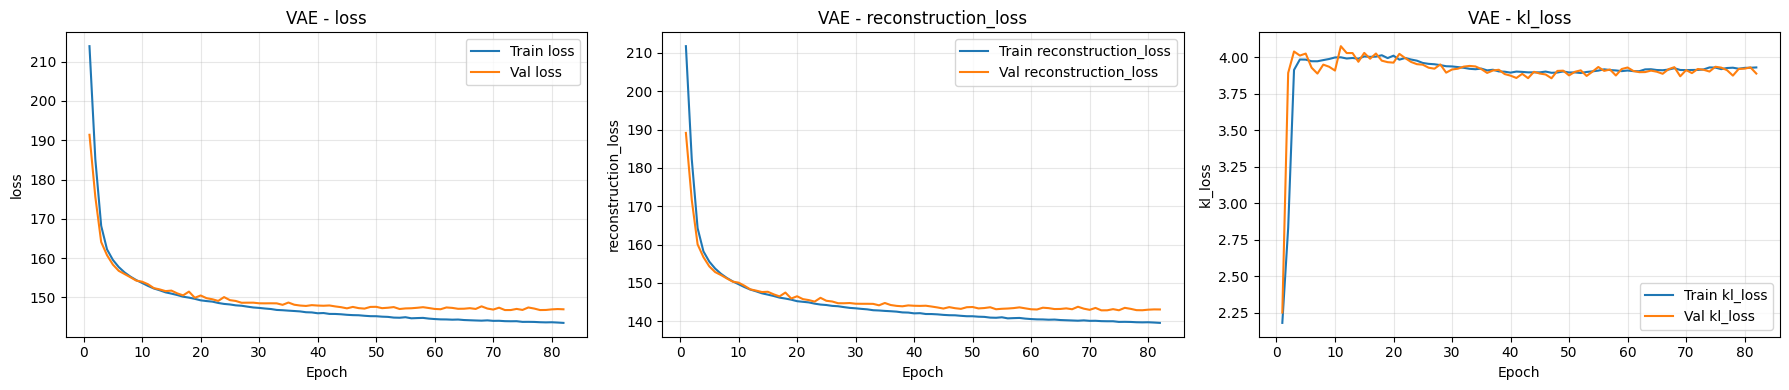

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


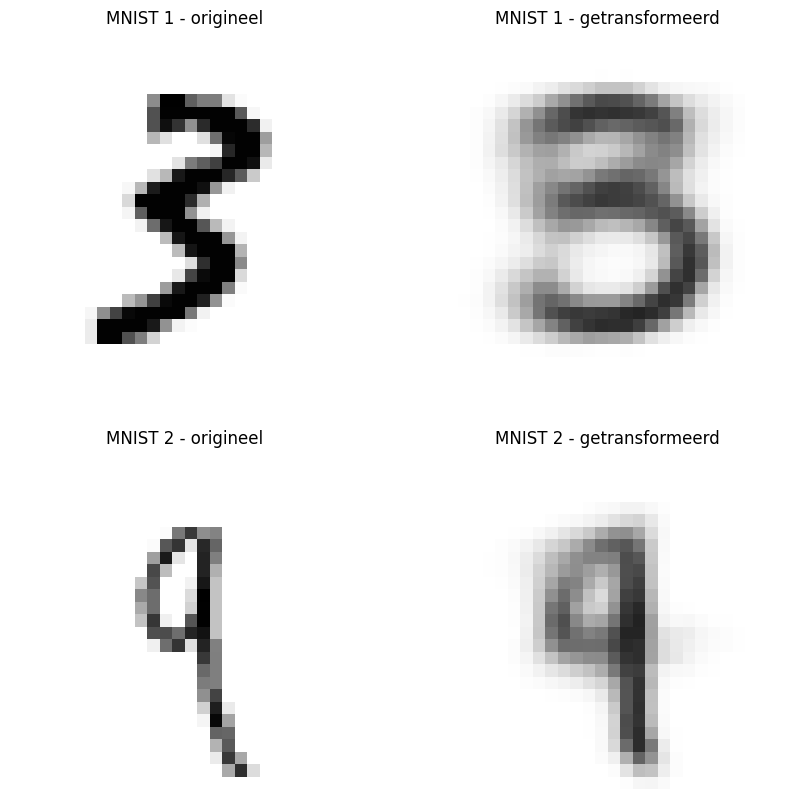

In [12]:
plot_training_curves(hist, title_prefix='VAE')

# Preview reconstruction using UNLABELED validation slice (no labeled data involved)
latent, _ = vae.encoder.predict(x_train)
xnew = vae.decoder.predict(latent)

plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
plt.imshow(1-x_train[1].reshape(28,28), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 1 - origineel')
plt.subplot(2,2,2)
plt.imshow(1-xnew[1,:,:,0], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 1 - getransformeerd')
plt.subplot(2,2,3)
plt.imshow(1-x_train[2].reshape(28,28), cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 2 - origineel')
plt.subplot(2,2,4)
plt.imshow(1-xnew[2,:,:,0], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('MNIST 2 - getransformeerd')
plt.show()

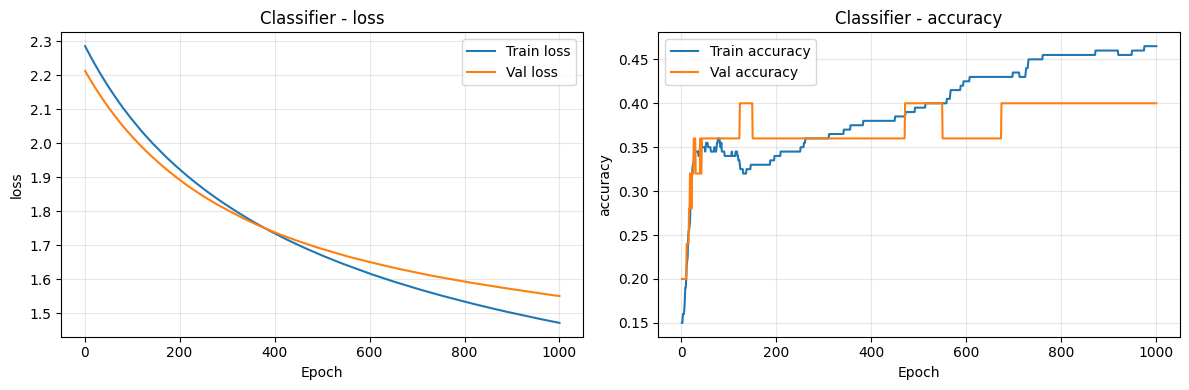

In [13]:
# Reusable plots for classifier training
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

## Iteratie 1 (Increase latent dim 16 / 32)

Na de evaluatie van het base model valt op dat de encoder en de decoder correct werken. Maar vervolgens lukt het de classifier niet om veel performance te verkrijgen met de kleine dataset, de latent representaties zorgen er dus niet voor dat de classifier beter instaat is de cijfers uit elkaar te halen. Om de classifier meer geven om mee te werken ga ik het aantal latent dimension verhogen. Een latente dimensie van 2 is onvoldoende voor de complexiteit van de data om alle nuttige features goed te capturen, volgens empirische analyse met ARD-VAE is te zien dat MNIST ongeveer 12–13 relevante latente dimensies bevat. Daarom wil ik voor iteratie 1 van het VAE-model een latente ruimte van 13 dimensies te gebruiken om voldoende representatiecapaciteit te bieden voor downstream classificatie. (Section 4.2 - Experiments on MNIST ) “For the MNIST dataset, the ARD-VAE consistently identifies approximately 12 to 13 relevant latent dimensions, independent of the initial size of the latent space. Increasing the initial latent dimensionality beyond this value does not increase the number of active latent variables, indicating that the intrinsic dimensionality of MNIST is captured within this range.”

In [21]:
latent_dim = 32

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - kl_loss: 1.1883 - loss: 200.5633 - reconstruction_loss: 199.3686 - val_kl_loss: 2.1969 - val_loss: 159.9463 - val_reconstruction_loss: 157.7491
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - kl_loss: 2.3545 - loss: 149.3258 - reconstruction_loss: 146.9707 - val_kl_loss: 2.3989 - val_loss: 143.8339 - val_reconstruction_loss: 141.4348
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - kl_loss: 2.6943 - loss: 135.3486 - reconstruction_loss: 132.6536 - val_kl_loss: 2.7157 - val_loss: 130.7076 - val_reconstruction_loss: 127.9916
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - kl_loss: 2.7043 - loss: 129.0380 - reconstruction_loss: 126.3332 - val_kl_loss: 2.6704 - val_loss: 127.4744 - val_reconstruction_loss: 124.8038
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - kl_loss: 2.6610 - loss: 126.5205 - reconstruction_loss: 123.8588 - val_kl_loss: 2.6676 - val_loss: 125.2335 - val_reconstruction_loss: 122.

In [22]:
# Save base VAE model and history using reusable function
paths = save_model_and_history(vae, hist, name='model_it1')

Saved weights → models\model_it1.weights.h5
Saved history → models\model_it1_hist.pkl


In [35]:
# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0400 - loss: 2.4813 - val_accuracy: 0.0400 - val_loss: 2.5059
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0650 - loss: 2.3400 - val_accuracy: 0.0800 - val_loss: 2.3780
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1400 - loss: 2.2115 - val_accuracy: 0.1600 - val_loss: 2.2595
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2600 - loss: 2.0997 - val_accuracy: 0.2400 - val_loss: 2.1510
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3550 - loss: 1.9969 - val_accuracy: 0.3200 - val_loss: 2.0518
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4100 - loss: 1.9033 - val_accuracy: 0.3200 - val_loss: 1.9623
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4200 - loss: 1.8227 - val_accuracy: 0.3600 - val_loss: 1.8802
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4400 - loss: 1.7476 - val_accuracy: 0.3600 - v

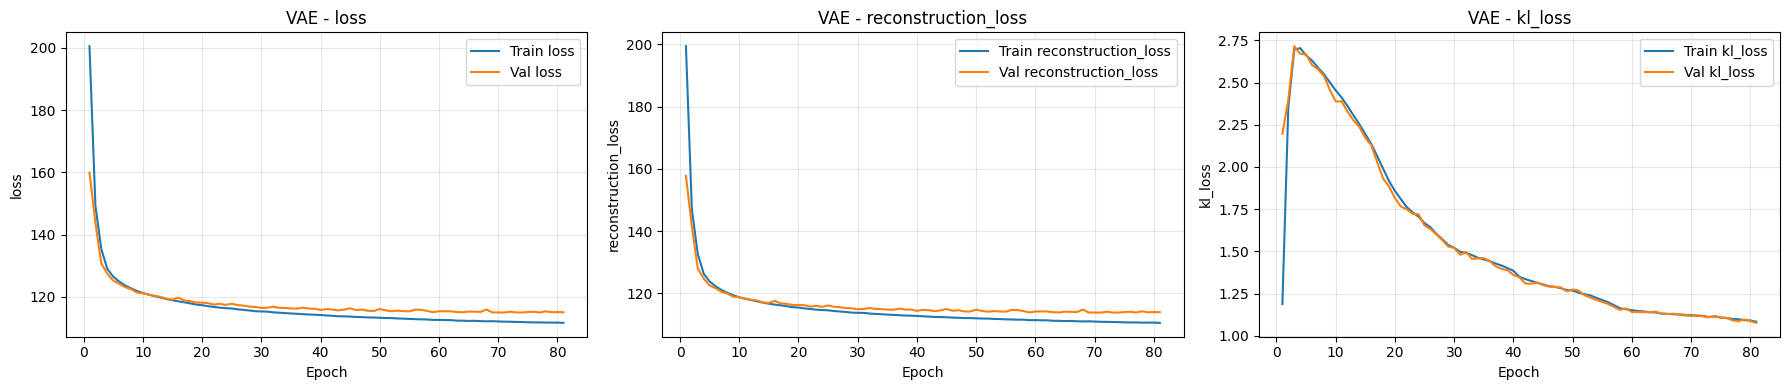

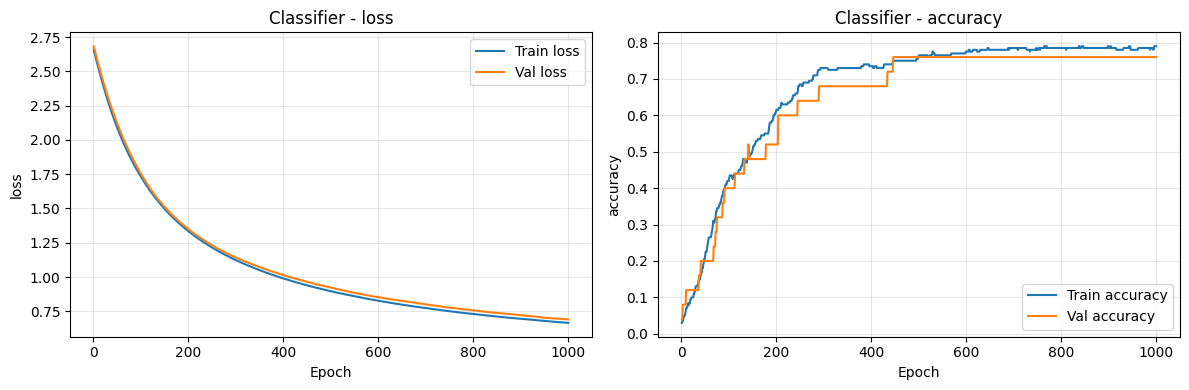

In [24]:
plot_training_curves(hist, title_prefix='VAE')
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

## Eval latent dims

De actieve latente dimensies worden bepaald op basis van de variantie van de latente gemiddelden over de dataset. Dimensies met een vrijwel nul-variantie worden beschouwd als ingestort (inactief), terwijl dimensies met een duidelijk hogere variantie actief zijn. De gekozen drempelwaarde wordt empirisch vastgesteld op basis van de visuele scheiding tussen deze twee regimes in de variantieverdeling, waarbij de drempel is geplaatst bij de kleinste dimensie die nog duidelijke variatie vertoont. Deze aanpak volgt de definitie van latente relevantie zoals beschreven in de literatuur, waarin irrelevante dimensies gekenmerkt worden door zeer lage, maar niet exact nul, variantie.

paragraaf 3.2 en 3.4
“The unwanted latent variables, through training, obtain very low variance.”

(paragraaf 3.4)
“The estimated variance for the collapsed dimensions (no effect on the decoder output) has relatively low but non-zero values.”

(paragraaf 3.4)
“Thus, the choice of a threshold or the percentage of variance (used in PCA) for selecting relevant dimensions that work under different scenarios is non-trivial.”

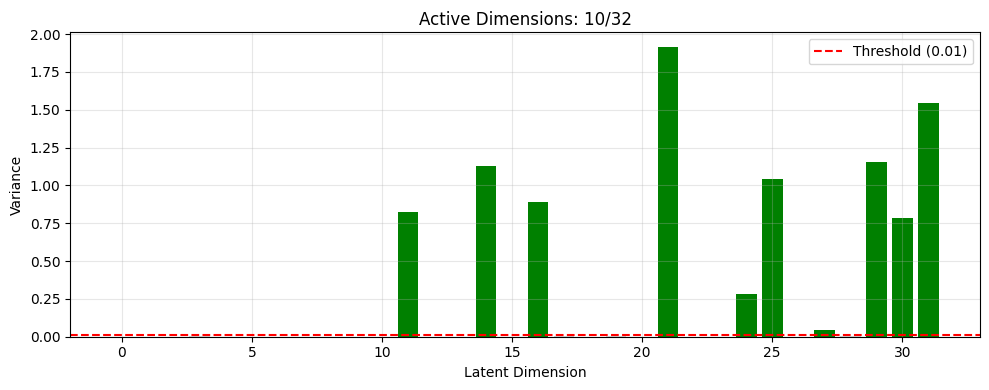

Active dimensions: 10/32
Active indices: [11, 14, 16, 21, 24, 25, 27, 29, 30, 31]
Variances: [3.53360723e-04 9.59918179e-05 1.21002406e-04 6.74386928e-03
 7.50462495e-05 2.07492601e-04 9.96675924e-04 1.40490200e-04
 2.59795252e-05 2.04639327e-05 2.93024234e-04 8.25509429e-01
 1.58203780e-04 7.72821659e-05 1.12736559e+00 3.70556256e-04
 8.90702903e-01 2.27730093e-03 9.47218541e-06 2.48103519e-03
 1.22188649e-03 1.91623163e+00 3.71133006e-04 1.92257387e-04
 2.80971408e-01 1.04061544e+00 5.68218893e-05 4.55930568e-02
 2.07450171e-03 1.15798283e+00 7.84414470e-01 1.54542542e+00]


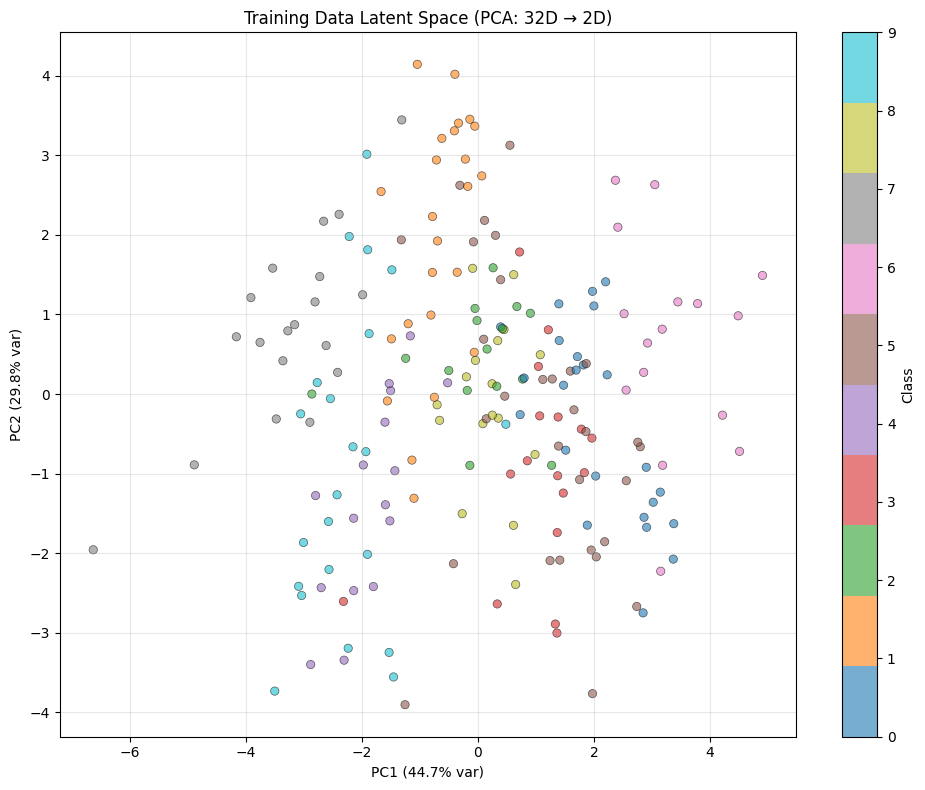

In [52]:
# After training your VAE, analyze it:
active_info = analyze_active_dimensions(vae, x_train, threshold=0.01)

# Visualize class separation in latent space:
z_encoded = plot_latent_space(vae, x_train, y_train, 
                               title='Training Data Latent Space',
                               method='pca')  # or 'tsne'



### Iteration 2 (increase beta)

4.1 QUALITATIVE BENCHMARKS, page 7
"While increasing β often leads to better disentanglement,
it may come at the cost of blurrier reconstructions and losing representations for some factors,
particularly those that correspond to only minor changes in pixel space."

In [117]:
latent_dim = 32

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


vae = VAE(encoder, decoder, beta=4.0)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100
  5/436 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - kl_loss: 6.5747e-04 - loss: 540.7532 - reconstruction_loss: 540.7506

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 0.6350 - loss: 200.2039 - reconstruction_loss: 197.6576 - val_kl_loss: 1.4435 - val_loss: 152.7718 - val_reconstruction_loss: 146.9979
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - kl_loss: 1.5646 - loss: 143.2351 - reconstruction_loss: 136.9759 - val_kl_loss: 1.5863 - val_loss: 137.6073 - val_reconstruction_loss: 131.2619
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - kl_loss: 1.5394 - loss: 135.7350 - reconstruction_loss: 129.5775 - val_kl_loss: 1.4736 - val_loss: 133.4514 - val_reconstruction_loss: 127.5568
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 1.4494 - loss: 132.1633 - reconstruction_loss: 126.3655 - val_kl_loss: 1.4197 - val_loss: 130.6542 - val_reconstruction_loss: 124.9753
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 1.3840 - loss: 129.8686 - reconstruction_loss: 124.3324 - val_kl_loss: 1.3718 - val_loss: 129.1572 - val_reconstruction_loss: 123.6698
Epoch 6

In [118]:
paths = save_model_and_history(vae, hist, name='model_it2_beta4')

Saved weights → models\model_it2_beta4.weights.h5
Saved history → models\model_it2_beta4_hist.pkl


In [120]:
# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2050 - loss: 2.3626 - val_accuracy: 0.2400 - val_loss: 2.2901
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2250 - loss: 2.2911 - val_accuracy: 0.2800 - val_loss: 2.2258
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2550 - loss: 2.2221 - val_accuracy: 0.2800 - val_loss: 2.1658
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2650 - loss: 2.1576 - val_accuracy: 0.2800 - val_loss: 2.1095
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2850 - loss: 2.0959 - val_accuracy: 0.3200 - val_loss: 2.0570
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3200 - loss: 2.0417 - val_accuracy: 0.3200 - val_loss: 2.0069
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3600 - loss: 1.9881 - val_accuracy: 0.3600 - val_loss: 1.9604
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4150 - loss: 1.9381 - val_accuracy: 0.4400 - v

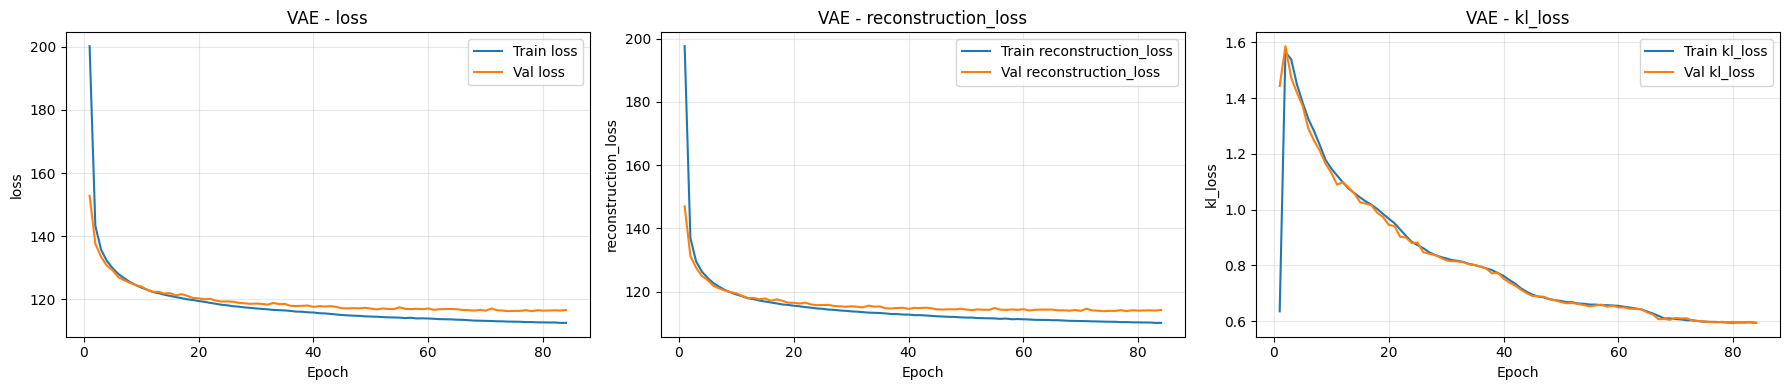

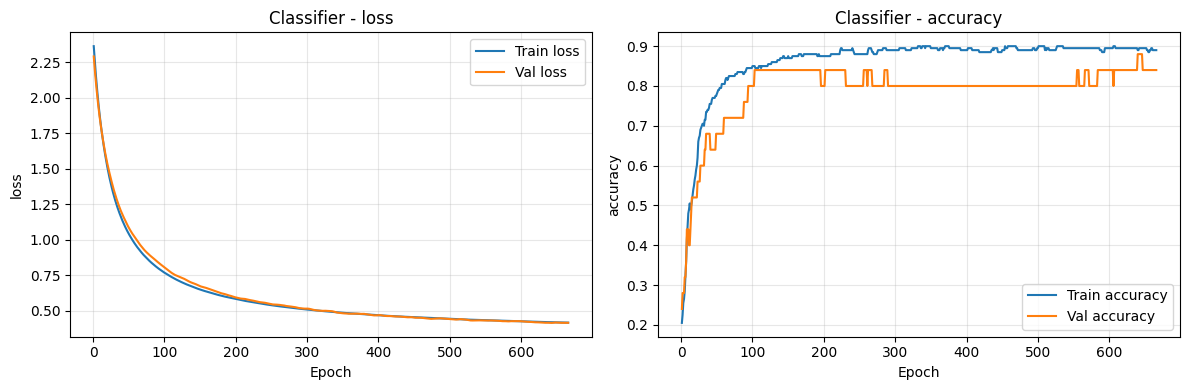

In [121]:
plot_training_curves(hist, title_prefix='VAE')
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

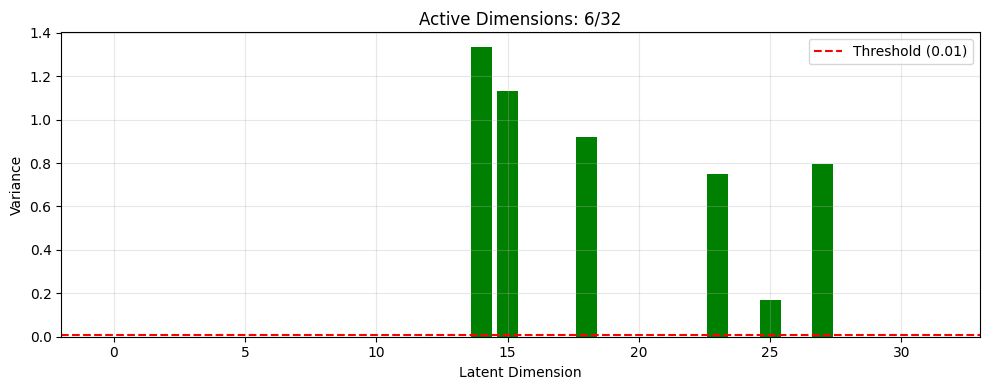

Active dimensions: 6/32
Active indices: [14, 15, 18, 23, 25, 27]
Variances: [1.1954572e-04 2.3240673e-05 1.2373002e-05 1.1988108e-05 1.5043238e-05
 1.4329184e-05 2.4034991e-05 7.8873512e-05 1.7260121e-05 3.7568396e-05
 6.1558174e-05 1.3445015e-05 3.5560362e-05 3.5322410e-05 1.3352202e+00
 1.1319321e+00 9.5444420e-06 2.6999704e-05 9.2065132e-01 9.0180592e-06
 3.8071765e-05 5.2553874e-06 1.7021335e-05 7.4824435e-01 2.5369392e-05
 1.6868129e-01 3.4200122e-05 7.9777396e-01 2.5350368e-05 1.1835587e-05
 1.5872623e-05 9.7866032e-06]


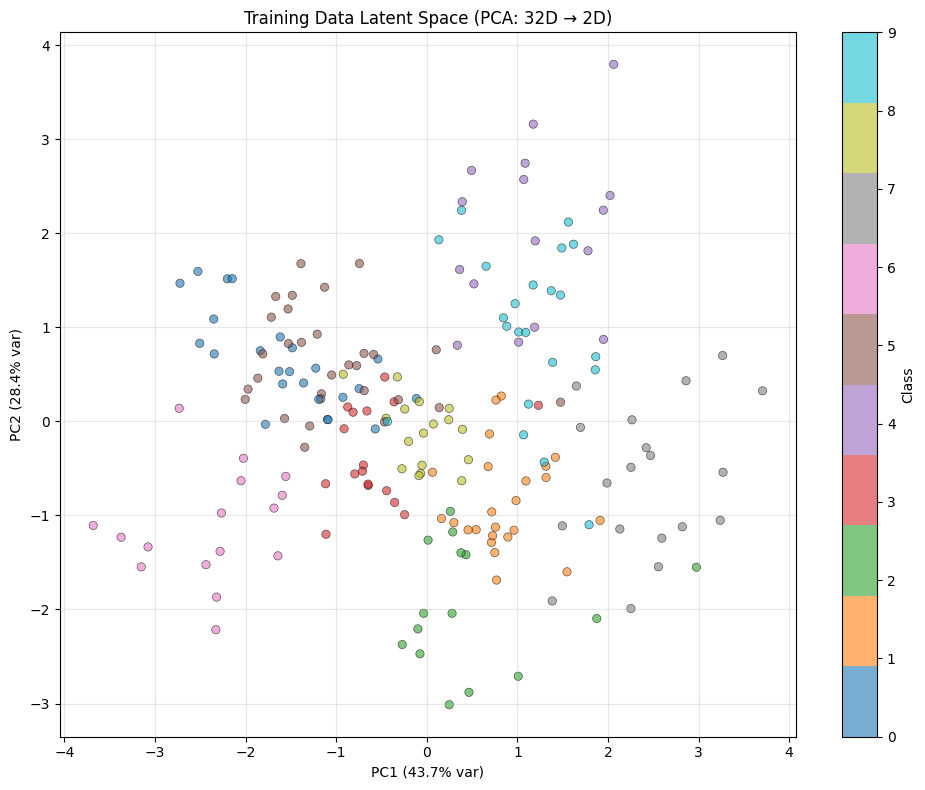

In [122]:
# After training your VAE, analyze it:
active_info = analyze_active_dimensions(vae, x_train, threshold=0.01)

# Visualize class separation in latent space:
z_encoded = plot_latent_space(vae, x_train, y_train, 
                               title='Training Data Latent Space',
                               method='pca')  # or 'tsne'

## Stop iterating VAE

### Iteratie 3 (Increase classifier complexity)

Of complexity toevoegen aan classifier, of encoder layers unfreezen

In [123]:
# Reload the saved VAE weights to reset encoder to pre-classifier-training state
# Run this cell before retraining the classifier if you've modified the encoder

loaded = load_vae_weights(vae, name='model_it2_beta4')
if loaded:
    print("✓ VAE encoder reset to saved weights")
    print("  You can now retrain the classifier with fresh encoder weights")
else:
    print("⚠ Could not load weights - using current in-memory VAE")

Loaded VAE weights from: models\model_it2_beta4.weights.h5
✓ VAE encoder reset to saved weights
  You can now retrain the classifier with fresh encoder weights


In [126]:
# VAE-based classifier (semi-supervised): freeze encoder, use z_mean features
# Reuse trained VAE encoder: load weights (if saved), then freeze

# weights_path = 'models/model_it1.weights.h5'
# loaded = load_vae_weights(vae, weights_path)
# if not loaded:
#     print("Using current in-memory VAE weights.")

# Freeze the encoder to keep features identical
vae.encoder.trainable = False
for layer in vae.encoder.layers[-2:]:
    layer.trainable = True

# Keep a reference if needed later
vae_encoder = vae.encoder


# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

# Minimal added capacity + regularization before softmax
# x = layers.Dense(64, activation="relu", name="vae_cls_dense")(z_mean)
# x = layers.Dropout(0.3, name="vae_cls_dropout")(x)
# cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(x)
# vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=100, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)


Loaded VAE weights from: models\model_it2_beta4.weights.h5
Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0300 - loss: 2.5132 - val_accuracy: 0.0000e+00 - val_loss: 2.5237
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0650 - loss: 2.4289 - val_accuracy: 0.0000e+00 - val_loss: 2.4461
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0900 - loss: 2.3528 - val_accuracy: 0.0800 - val_loss: 2.3733
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1500 - loss: 2.2826 - val_accuracy: 0.0800 - val_loss: 2.3045
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1650 - loss: 2.2135 - val_accuracy: 0.1200 - val_loss: 2.2399
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1650 - loss: 2.1483 - val_accuracy: 0.1200 - val_loss: 2.1790
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1950 - loss: 2.0885 - val_accuracy: 0.1600 - val_loss: 2.1215
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30m

## Iteration 4 (unfreeze encoder)

In [203]:
loaded = load_vae_weights(vae, name='model_it2_beta4')

# VAE-based classifier (semi-supervised): freeze encoder, use z_mean features
# Reuse trained VAE encoder: load weights (if saved), then freeze

# weights_path = 'models/model_it1.weights.h5'
# loaded = load_vae_weights(vae, weights_path)
# if not loaded:
#     print("Using current in-memory VAE weights.")

# Freeze the encoder to keep features identical
# vae.encoder.trainable = False
# for layer in vae.encoder.layers[-1:]:
#     layer.trainable = True

# Keep a reference if needed later
vae_encoder = vae.encoder


# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

# Minimal added capacity + regularization before softmax
x = layers.Dense(64, activation="relu", name="vae_cls_dense")(z_mean)
x = layers.Dropout(0.3, name="vae_cls_dropout")(x)
cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(x)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

# cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
# vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

initial_lr = 0.005  # extra aggressive start
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=3000,
    decay_rate=0.96,
    staircase=False,
)

vae_classifier.compile(optimizer=optimizers.Adam(learning_rate=lr_schedule),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=200, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)


Loaded VAE weights from: models\model_it2_beta4.weights.h5
Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1600 - loss: 2.5731 - val_accuracy: 0.1200 - val_loss: 2.5973
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1750 - loss: 2.5354 - val_accuracy: 0.1200 - val_loss: 2.5603
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1800 - loss: 2.4970 - val_accuracy: 0.1200 - val_loss: 2.5245
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1800 - loss: 2.4606 - val_accuracy: 0.1200 - val_loss: 2.4899
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1900 - loss: 2.4258 - val_accuracy: 0.1200 - val_loss: 2.4558
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1900 - loss: 2.3911 - val_accuracy: 0.1200 - val_loss: 2.4230
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2000 - loss: 2.3570 - val_accuracy: 0.1600 - val_loss: 2.3908
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step -

In [204]:
# After training completes with early stopping
print("Training completed with early stopping")
print(f"Total epochs run: {len(vae_cls_hist.history['loss'])}")

# Find the best epoch (where validation loss was lowest)
val_losses = vae_cls_hist.history['val_loss']
best_epoch = np.argmin(val_losses) + 1  # +1 because epochs start at 1

# Get metrics from the best epoch (index is 0-based)
best_idx = best_epoch - 1
best_train_loss = vae_cls_hist.history['loss'][best_idx]
best_val_loss = vae_cls_hist.history['val_loss'][best_idx]
best_train_acc = vae_cls_hist.history['accuracy'][best_idx]
best_val_acc = vae_cls_hist.history['val_accuracy'][best_idx]

print(f"\n✓ Best weights restored from epoch {best_epoch}/{len(val_losses)}")
print(f"  Train Loss: {best_train_loss:.4f}")
print(f"  Val Loss: {best_val_loss:.4f}")
print(f"  Train Accuracy: {best_train_acc:.4f}")
print(f"  Val Accuracy: {best_val_acc:.4f}")

Training completed with early stopping
Total epochs run: 1000

✓ Best weights restored from epoch 1000/1000
  Train Loss: 0.4452
  Val Loss: 0.4474
  Train Accuracy: 0.8950
  Val Accuracy: 0.8000


In [ ]:
# Jouw code hier, voeg gerust cellen toe

> Jouw antwoorden hier, voeg gerust cellen toe)    verbose=1,    callbacks=[early_stop],    batch_size=128,    epochs=1000,    validation_data=(x_val, y_val),    x_train, y_train,vae_cls_hist = vae_classifier.fit()    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1early_stop = keras.callbacks.EarlyStopping(                       metrics=["accuracy"])                        loss="sparse_categorical_crossentropy",vae_classifier.compile(optimizer=optimizers.Adam(),vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)# vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")# cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(x)# x = layers.Dropout(0.3, name="vae_cls_dropout")(x)# x = layers.Dense(64, activation="relu", name="vae_cls_dense")(z_mean)# Minimal added capacity + regularization before softmaxz_mean, z_log_var = vae.encoder(clf_inputs)clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")# Build classifier that uses z_mean as featuresvae_encoder = vae.encoder# Keep a reference if needed later#     layer.trainable = True# for layer in encoder.layers[-3:]:vae.encoder.trainable = False# Freeze the encoder to keep features identical    print("Using current in-memory VAE weights.")if not loaded:loaded = load_vae_weights(vae, name='model_it1')

### Deel 3

Evalueer je model.

## TEST DATA

In [206]:
# Evaluate the classifier on the test set
test_loss, test_accuracy = vae_classifier.evaluate(x_test, y_test, verbose=0)

print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("=" * 50)

TEST SET EVALUATION
Test Loss: 0.3105
Test Accuracy: 0.9200


### Confusion matrix

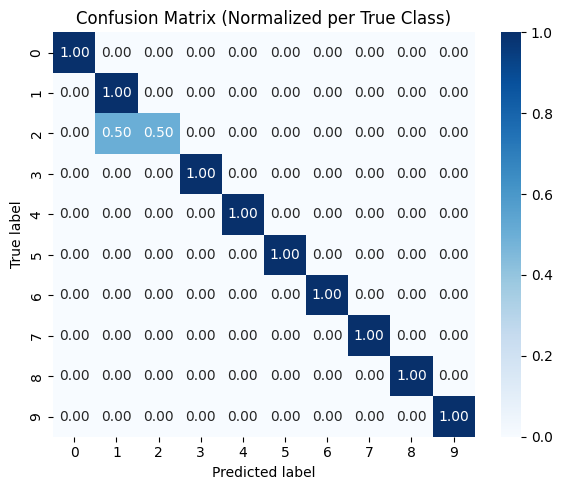

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.75      1.00      0.86         3
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         3

    accuracy                           0.96        25
   macro avg       0.97      0.95      0.95        25
weighted avg       0.97      0.96      0.96        25



In [91]:
y_prob = vae_classifier.predict(x_val, verbose=0)

# Align y_true shape
y_true = y_val
if y_true.ndim > 1:
    # If one-hot, reduce to class indices
    try:
        y_true = np.argmax(y_true, axis=1)
    except Exception:
        y_true = y_true.ravel()

# Derive class predictions
if y_prob.ndim == 1 or (y_prob.ndim == 2 and y_prob.shape[1] == 1):
    # Binary case
    y_pred = (y_prob.ravel() >= 0.5).astype(int)
else:
    # Multiclass case
    y_pred = np.argmax(y_prob, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Confusion Matrix (Normalized per True Class)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

> Jouw antwoorden hier, voeg gerust cellen toe

### Sources

[1] Saha, A., et al. ARD-VAE: A Statistical Formulation to Find the Relevant Latent Dimensions of Variational Autoencoders, 2025.
Beschikbaar via: https://pmc.ncbi.nlm.nih.gov/articles/PMC12747167/

# Citing example

Als je gebruik maakt van bronnen om jouw keuzes te verantwoorden willen we bij deze opdracht het volgende zien:
- De bronverwijzing (online link indien beschikbaar)
- De uitspraak die jij doet
- Paragraafnummer uit de bron waar je deze uitspraak op baseert
- Een letterlijke quote uit de bron waar je jouw uitspraak op baseert

(Merk op: dit is veel uitgebreider dan wat er meestal in rapporten verwacht wordt, en is puur bedoeld te controleren of de student correct kan verwijzen.)

Voorbeeld:
> De laatste jaren zijn GANs veel minder populair als generatieve modellen [1] (H17: "(GANs) have gradually fallen out of fashion in recent years and have been all but replaced by diffusion models")
>
> ...
>
> Bronnenlijst:
>
> [1] F. Chollet and M. Watson, Deep Learning in Python, 3rd edition, Manning, 2025. 

In [ ]:
# encoder.summary()

# for layer in encoder.layers:
#     layer.output_shape = layer.output.shape
# visualkeras.layered_view(encoder, scale_z=0.03, legend=True)

# decoder.summary()

# for layer in decoder.layers:
#     layer.output_shape = layer.output.shape
# visualkeras.layered_view(decoder, scale_z = 0.03, legend=True)

# vae.summary()